In [15]:
# ═══════════════════════════════════════════════
# CELL 1: Imports & Setup
# ═══════════════════════════════════════════════
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path
from tqdm import tqdm
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11})

print("All imports loaded")


All imports loaded


In [16]:
# ═══════════════════════════════════════════════
# CELL 2: GPU Check
# ═══════════════════════════════════════════════
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU   : {torch.cuda.get_device_name(0)}")
    print(f"VRAM  : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


Device: cuda
GPU   : Tesla P100-PCIE-16GB
VRAM  : 15.9 GB


In [17]:
# ═══════════════════════════════════════════════
# CELL 3: Config — Edit checkpoint paths here
# ═══════════════════════════════════════════════

# ── CheXpert Dataset ──────────────────────────
DATA_ROOT  = Path("/kaggle/input/datasets/ashery/chexpert")
VALID_CSV  = DATA_ROOT / "valid.csv"
IMAGE_ROOT = DATA_ROOT
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 14

# ── CheXpert 14 Label Names (exact CSV column names) ──
LABEL_NAMES = [
    "No Finding", "Enlarged Cardiomediastinum", "Cardiomegaly",
    "Lung Opacity", "Lung Lesion", "Edema", "Consolidation",
    "Pneumonia", "Atelectasis", "Pneumothorax", "Pleural Effusion",
    "Pleural Other", "Fracture", "Support Devices"
]

# ── Model Checkpoints ─────────────────────────
# Edit these paths to match where each .pth file is
CHECKPOINTS = {
    "ResNet50": (
        "/kaggle/input/notebooks/ravinduwellalage2/"
        "chexpert-resnet50/best_model.pth"
    ),
    "DenseNet-121": (
        "/kaggle/input/notebooks/d1nushi/"
        "chexpert-densenet-121/best_densenet121_clahe.pth"
    ),
    "EfficientNet-B3": (
        "/kaggle/input/notebooks/ravinduwellalage2/"
        "efficientnet-b3/best_efficientnet_b3.pth"
    ),
    # ↓ Update this filename to match whatever you named the .pth file
    "ViT-B16": (
        "/kaggle/input/datasets/ravinduwellalage2/vit-b16-chexpert-checkpoint/best_vit_b16.pth"
    ),
}
# ── Auto-detect which checkpoints exist ───────
AVAILABLE = {k: v for k, v in CHECKPOINTS.items() if Path(v).exists()}
MISSING    = {k: v for k, v in CHECKPOINTS.items() if not Path(v).exists()}

print("=" * 60)
print("CHECKPOINT STATUS")
print("=" * 60)
for m, p in AVAILABLE.items():
    size = Path(p).stat().st_size / 1024**2
    print(f"  {m:20s} ({size:.1f} MB)")
for m, p in MISSING.items():
    print(f"  {m:20s} — NOT FOUND: {p}")
print(f"\nWill evaluate {len(AVAILABLE)} model(s)")


CHECKPOINT STATUS
  ✅ ResNet50             (269.8 MB)
  ✅ DenseNet-121         (80.7 MB)
  ✅ EfficientNet-B3      (123.5 MB)
  ✅ ViT-B16              (982.2 MB)

Will evaluate 4 model(s)


In [18]:
# ── Path verification ──────────────────────────────────────────────
print("=" * 55)
print("CHECKPOINT FILE CHECK")
print("=" * 55)
all_ok = True
for name, path in CHECKPOINTS.items():
    exists = Path(path).exists()
    if exists:
        size_mb = Path(path).stat().st_size / 1024**2
        print(f"  {name:20s}  {size_mb:.1f} MB  →  found")
    else:
        print(f"  {name:20s}  NOT FOUND: {path}")
        all_ok = False

print("=" * 55)
if all_ok:
    print("All 4 checkpoints found — ready to evaluate!")
else:
    print("Fix missing paths above before continuing")


CHECKPOINT FILE CHECK
  ✅ ResNet50              269.8 MB  →  found
  ✅ DenseNet-121          80.7 MB  →  found
  ✅ EfficientNet-B3       123.5 MB  →  found
  ✅ ViT-B16               982.2 MB  →  found
✅ All 4 checkpoints found — ready to evaluate!


In [19]:
# ═══════════════════════════════════════════════
# CELL 4: Model Architecture Definitions
# ═══════════════════════════════════════════════

# ── ResNet50 ──────────────────────────────────
class ChestXRayResNet50(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        backbone = models.resnet50(weights=None)
        in_features = backbone.fc.in_features       # 2048
        backbone.fc = nn.Identity()
        self.backbone   = backbone
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.classifier(self.backbone(x))


# ── DenseNet-121 ──────────────────────────────
class ChestXRayDenseNet121(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        backbone = models.densenet121(weights=None)
        in_features = backbone.classifier.in_features  # 1024
        backbone.classifier = nn.Identity()
        self.backbone   = backbone
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))


# ── EfficientNet-B3 ───────────────────────────
class ChestXRayEfficientNetB3(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        backbone = models.efficientnet_b3(weights=None)
        in_features = backbone.classifier[1].in_features  # 1536
        backbone.classifier = nn.Identity()
        self.backbone   = backbone
        self.classifier = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.classifier(self.backbone(x))


# ── ViT-B16 ───────────────────────────────────
class ChestXRayViTB16(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()
        self.backbone = models.vit_b_16(weights=None)
        in_features = self.backbone.heads.head.in_features  # 768
        self.backbone.heads.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)


# Map model name → class
MODEL_CLASSES = {
    "ResNet50":       ChestXRayResNet50,
    "DenseNet-121":   ChestXRayDenseNet121,
    "EfficientNet-B3": ChestXRayEfficientNetB3,
    "ViT-B16":        ChestXRayViTB16,
}

print("All 4 model architectures defined")


✅ All 4 model architectures defined


In [20]:
# ═══════════════════════════════════════════════
# CELL 5: CheXpert Validation Dataset
# ═══════════════════════════════════════════════

class CheXpertValidDataset(Dataset):
    """
    CheXpert validation set (234 images).
    valid.csv has no uncertain labels — only 0 and 1.
    NaN is treated as 0 (condition absent).
    """
    def __init__(self, csv_path, image_root, transform):
        self.df         = pd.read_csv(csv_path)
        self.image_root = Path(image_root)
        self.transform  = transform

        # Fill NaN with 0
        self.df[LABEL_NAMES] = self.df[LABEL_NAMES].fillna(0)
        print(f"Loaded {len(self.df)} validation images")

        # Print class distribution
        print("\n  Positive cases per class:")
        for col in LABEL_NAMES:
            n = int(self.df[col].sum())
            print(f"    {col:35s}: {n:3d}")

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Handle path prefix
        raw_path = row["Path"]
        relative = (raw_path.replace("CheXpert-v1.0-small/", "")
                            .replace("CheXpert-v1.0/", ""))
        img_path = self.image_root / relative

        image  = Image.open(img_path).convert("RGB")
        labels = torch.tensor(
            row[LABEL_NAMES].values.astype(np.float32)
        )

        if self.transform:
            image = self.transform(image)

        return image, labels


val_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

val_dataset = CheXpertValidDataset(VALID_CSV, IMAGE_ROOT, val_transform)
val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

print(f"\nDataLoader ready — {len(val_loader)} batches")


✅ Loaded 234 validation images

  Positive cases per class:
    No Finding                         :  38
    Enlarged Cardiomediastinum         : 109
    Cardiomegaly                       :  68
    Lung Opacity                       : 126
    Lung Lesion                        :   1
    Edema                              :  45
    Consolidation                      :  33
    Pneumonia                          :   8
    Atelectasis                        :  80
    Pneumothorax                       :   8
    Pleural Effusion                   :  67
    Pleural Other                      :   1
    Fracture                           :   0
    Support Devices                    : 107

✅ DataLoader ready — 8 batches


In [21]:
# ═══════════════════════════════════════════════
# CELL 6: Evaluation Function
# ═══════════════════════════════════════════════

def load_checkpoint(model, ckpt_path):
    """Robust checkpoint loader — handles PyTorch 2.6 weights_only change."""
    
    # First try strict mode (safe)
    try:
        ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=True)
        print(f"   Loaded with weights_only=True (safe mode)")
    except Exception:
        # Fall back for checkpoints saved with numpy / full state
        try:
            import numpy as np
            import torch.serialization as ts
            ts.add_safe_globals([np.core.multiarray.scalar])
        except Exception:
            pass
        ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        print(f"   Loaded with weights_only=False (trusted source)")

    # Detect format
    if isinstance(ckpt, dict):
        if 'model_state_dict' in ckpt:
            state_dict = ckpt['model_state_dict']
        elif 'state_dict' in ckpt:
            state_dict = ckpt['state_dict']
        elif 'model' in ckpt:
            state_dict = ckpt['model']
        else:
            state_dict = ckpt
    else:
        state_dict = ckpt

    # Strip DataParallel prefix if present
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}

    missing, unexpected = model.load_state_dict(state_dict, strict=False)
    if missing:
        print(f"Missing keys  : {len(missing)}")
    if unexpected:
        print(f"Unexpected keys: {len(unexpected)}")

    return model



def evaluate_model(model_name, ckpt_path):
    """
    Run full evaluation for one model.
    Returns dict with per-class AUROC and macro-AUROC.
    """
    print(f"\n{'='*60}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*60}")

    # Build & load model
    model_class = MODEL_CLASSES[model_name]
    model = model_class(num_classes=NUM_CLASSES)
    model = load_checkpoint(model, ckpt_path)
    model = model.to(DEVICE)
    model.eval()
    print(f"Checkpoint loaded")

    # Collect predictions
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Running inference"):
            images = images.to(DEVICE)
            logits = model(images)
            probs  = torch.sigmoid(logits).cpu().numpy()
            all_preds.append(probs)
            all_labels.append(labels.numpy())

    all_preds  = np.concatenate(all_preds,  axis=0)   # [N, 14]
    all_labels = np.concatenate(all_labels, axis=0)   # [N, 14]

    # Per-class AUROC
    per_class_auroc = {}
    for i, label in enumerate(LABEL_NAMES):
        n_pos = int(all_labels[:, i].sum())
        if n_pos >= 3:  # Need at least 3 positive cases
            try:
                auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
                per_class_auroc[label] = round(float(auc), 4)
            except Exception as e:
                per_class_auroc[label] = None
        else:
            per_class_auroc[label] = None   # Too few positives
            print(f"Skipping '{label}' — only {n_pos} positive cases")

    # Macro-AUROC (average of valid classes only)
    valid_aucs = [v for v in per_class_auroc.values() if v is not None]
    macro_auroc = round(float(np.mean(valid_aucs)), 4)

    print(f"\n  Macro-AUROC : {macro_auroc:.4f}")
    print(f"  Classes used: {len(valid_aucs)}/{NUM_CLASSES}")

    return {
        'per_class': per_class_auroc,
        'macro':     macro_auroc,
        'n_valid':   len(valid_aucs)
    }

print("Evaluation function ready")


Evaluation function ready


In [22]:
# ═══════════════════════════════════════════════
# CELL 7: Run Evaluation for All Available Models
# ═══════════════════════════════════════════════

ALL_RESULTS = {}

for model_name, ckpt_path in AVAILABLE.items():
    ALL_RESULTS[model_name] = evaluate_model(model_name, ckpt_path)

# Known macro-AUROC from training (for models not yet evaluated)
KNOWN_AUROC = {
    "ResNet50":        0.8027,
    "DenseNet-121":    0.7931,
    "EfficientNet-B3": 0.7927,
    "ViT-B16":         0.7928,
}

print("\n" + "=" * 60)
print("EVALUATION COMPLETE — MACRO-AUROC SUMMARY")
print("=" * 60)
for m, v in KNOWN_AUROC.items():
    src = "Test set" if m in ALL_RESULTS else "Val (training log)"
    auc = ALL_RESULTS[m]['macro'] if m in ALL_RESULTS else v
    print(f"  {m:20s}: {auc:.4f}   [{src}]")



Evaluating: ResNet50
   Loaded with weights_only=True (safe mode)
Checkpoint loaded


Running inference: 100%|██████████| 8/8 [00:01<00:00,  7.43it/s]


Skipping 'Lung Lesion' — only 1 positive cases
Skipping 'Pleural Other' — only 1 positive cases
Skipping 'Fracture' — only 0 positive cases

  Macro-AUROC : 0.8230
  Classes used: 11/14

Evaluating: DenseNet-121
   Loaded with weights_only=False (trusted source)
Checkpoint loaded


Running inference: 100%|██████████| 8/8 [00:00<00:00,  9.37it/s]


Skipping 'Lung Lesion' — only 1 positive cases
Skipping 'Pleural Other' — only 1 positive cases
Skipping 'Fracture' — only 0 positive cases

  Macro-AUROC : 0.8247
  Classes used: 11/14

Evaluating: EfficientNet-B3
   Loaded with weights_only=False (trusted source)
Missing keys  : 2
Unexpected keys: 2
Checkpoint loaded


Running inference: 100%|██████████| 8/8 [00:00<00:00,  9.23it/s]


Skipping 'Lung Lesion' — only 1 positive cases
Skipping 'Pleural Other' — only 1 positive cases
Skipping 'Fracture' — only 0 positive cases

  Macro-AUROC : 0.4916
  Classes used: 11/14

Evaluating: ViT-B16
   Loaded with weights_only=False (trusted source)
Missing keys  : 152
Unexpected keys: 154
Checkpoint loaded


Running inference: 100%|██████████| 8/8 [00:01<00:00,  4.95it/s]

Skipping 'Lung Lesion' — only 1 positive cases
Skipping 'Pleural Other' — only 1 positive cases
Skipping 'Fracture' — only 0 positive cases

  Macro-AUROC : 0.5075
  Classes used: 11/14

EVALUATION COMPLETE — MACRO-AUROC SUMMARY
  ResNet50            : 0.8230   [Test set]
  DenseNet-121        : 0.8247   [Test set]
  EfficientNet-B3     : 0.4916   [Test set]
  ViT-B16             : 0.5075   [Test set]


In [23]:
# ═══════════════════════════════════════════════
# CELL 8: Per-Class AUROC Table for Best Model
# ═══════════════════════════════════════════════

BEST_MODEL = "ResNet50"
best_results = ALL_RESULTS[BEST_MODEL]

print("=" * 60)
print(f"PER-CLASS AUROC — {BEST_MODEL}")
print(f"Macro-AUROC: {best_results['macro']:.4f}")
print("=" * 60)
print(f"  {'Disease Class':<35} {'AUROC':>8}  {'Performance'}")
print("  " + "-" * 58)

for cls, auc in best_results['per_class'].items():
    if auc is not None:
        if auc >= 0.80:
            perf = "🟢 Strong"
        elif auc >= 0.70:
            perf = "🟡 Moderate"
        else:
            perf = "🔴 Weak"
        print(f"  {cls:<35} {auc:>8.4f}  {perf}")
    else:
        print(f"  {cls:<35} {'N/A':>8}  ⚪ Insufficient data")

print("=" * 60)
print(f"  Macro-AUROC (valid classes): {best_results['macro']:.4f}")

# Save as CSV
rows = []
for cls, auc in best_results['per_class'].items():
    rows.append({'Disease': cls, f'{BEST_MODEL}_AUROC': auc})
df_table = pd.DataFrame(rows)
df_table.to_csv('/kaggle/working/per_class_auroc_resnet50.csv', index=False)
print("\nSaved → per_class_auroc_resnet50.csv")


PER-CLASS AUROC — ResNet50
Macro-AUROC: 0.8230
  Disease Class                          AUROC  Performance
  ----------------------------------------------------------
  No Finding                            0.8786  🟢 Strong
  Enlarged Cardiomediastinum            0.5832  🔴 Weak
  Cardiomegaly                          0.8000  🟢 Strong
  Lung Opacity                          0.9236  🟢 Strong
  Lung Lesion                              N/A  ⚪ Insufficient data
  Edema                                 0.9309  🟢 Strong
  Consolidation                         0.9236  🟢 Strong
  Pneumonia                             0.6444  🔴 Weak
  Atelectasis                           0.7381  🟡 Moderate
  Pneumothorax                          0.7655  🟡 Moderate
  Pleural Effusion                      0.9224  🟢 Strong
  Pleural Other                            N/A  ⚪ Insufficient data
  Fracture                                 N/A  ⚪ Insufficient data
  Support Devices                       0.9423  🟢 Strong
 

In [26]:
# ── Per-Class AUROC for DenseNet-121 ─────────────────────────────────────────
MODEL     = "DenseNet-121"
results   = ALL_RESULTS[MODEL]

# ── Console printout ──────────────────────────────────────────────────────────
print("=" * 60)
print(f"PER-CLASS AUROC  ·  {MODEL}")
print(f"Macro-AUROC: {results['macro']:.4f}")
print("=" * 60)
print(f"{'Disease Class':35s} {'AUROC':>8s}  Performance")
print("-" * 60)

for cls, auc in results['per_class'].items():
    if auc is not None:
        perf = "Strong" if auc >= 0.80 else "Moderate" if auc >= 0.70 else "Weak"
        print(f"{cls:35s} {auc:8.4f}  {perf}")
    else:
        print(f"{cls:35s} {'NA':>8s}  Insufficient data")

print("=" * 60)
print(f"Macro-AUROC valid classes): {results['macro']:.4f}")

# ── Save to CSV ───────────────────────────────────────────────────────────────
rows  = [{"Disease": cls, f"{MODEL} AUROC": auc}
         for cls, auc in results["per_class"].items()]
table = pd.DataFrame(rows)
table.to_csv("/kaggle/working/per_class_auroc_densenet121.csv", index=False)
print("\n✔  per_class_auroc_densenet121.csv saved")


PER-CLASS AUROC  ·  DenseNet-121
Macro-AUROC: 0.8247
Disease Class                          AUROC  Performance
------------------------------------------------------------
No Finding                            0.8965  Strong
Enlarged Cardiomediastinum            0.5310  Weak
Cardiomegaly                          0.8078  Strong
Lung Opacity                          0.9015  Strong
Lung Lesion                               NA  Insufficient data
Edema                                 0.9319  Strong
Consolidation                         0.8628  Strong
Pneumonia                             0.6930  Weak
Atelectasis                           0.8241  Strong
Pneumothorax                          0.8048  Strong
Pleural Effusion                      0.9178  Strong
Pleural Other                             NA  Insufficient data
Fracture                                  NA  Insufficient data
Support Devices                       0.9001  Strong
Macro-AUROC valid classes): 0.8247

✔  per_class_auroc_de

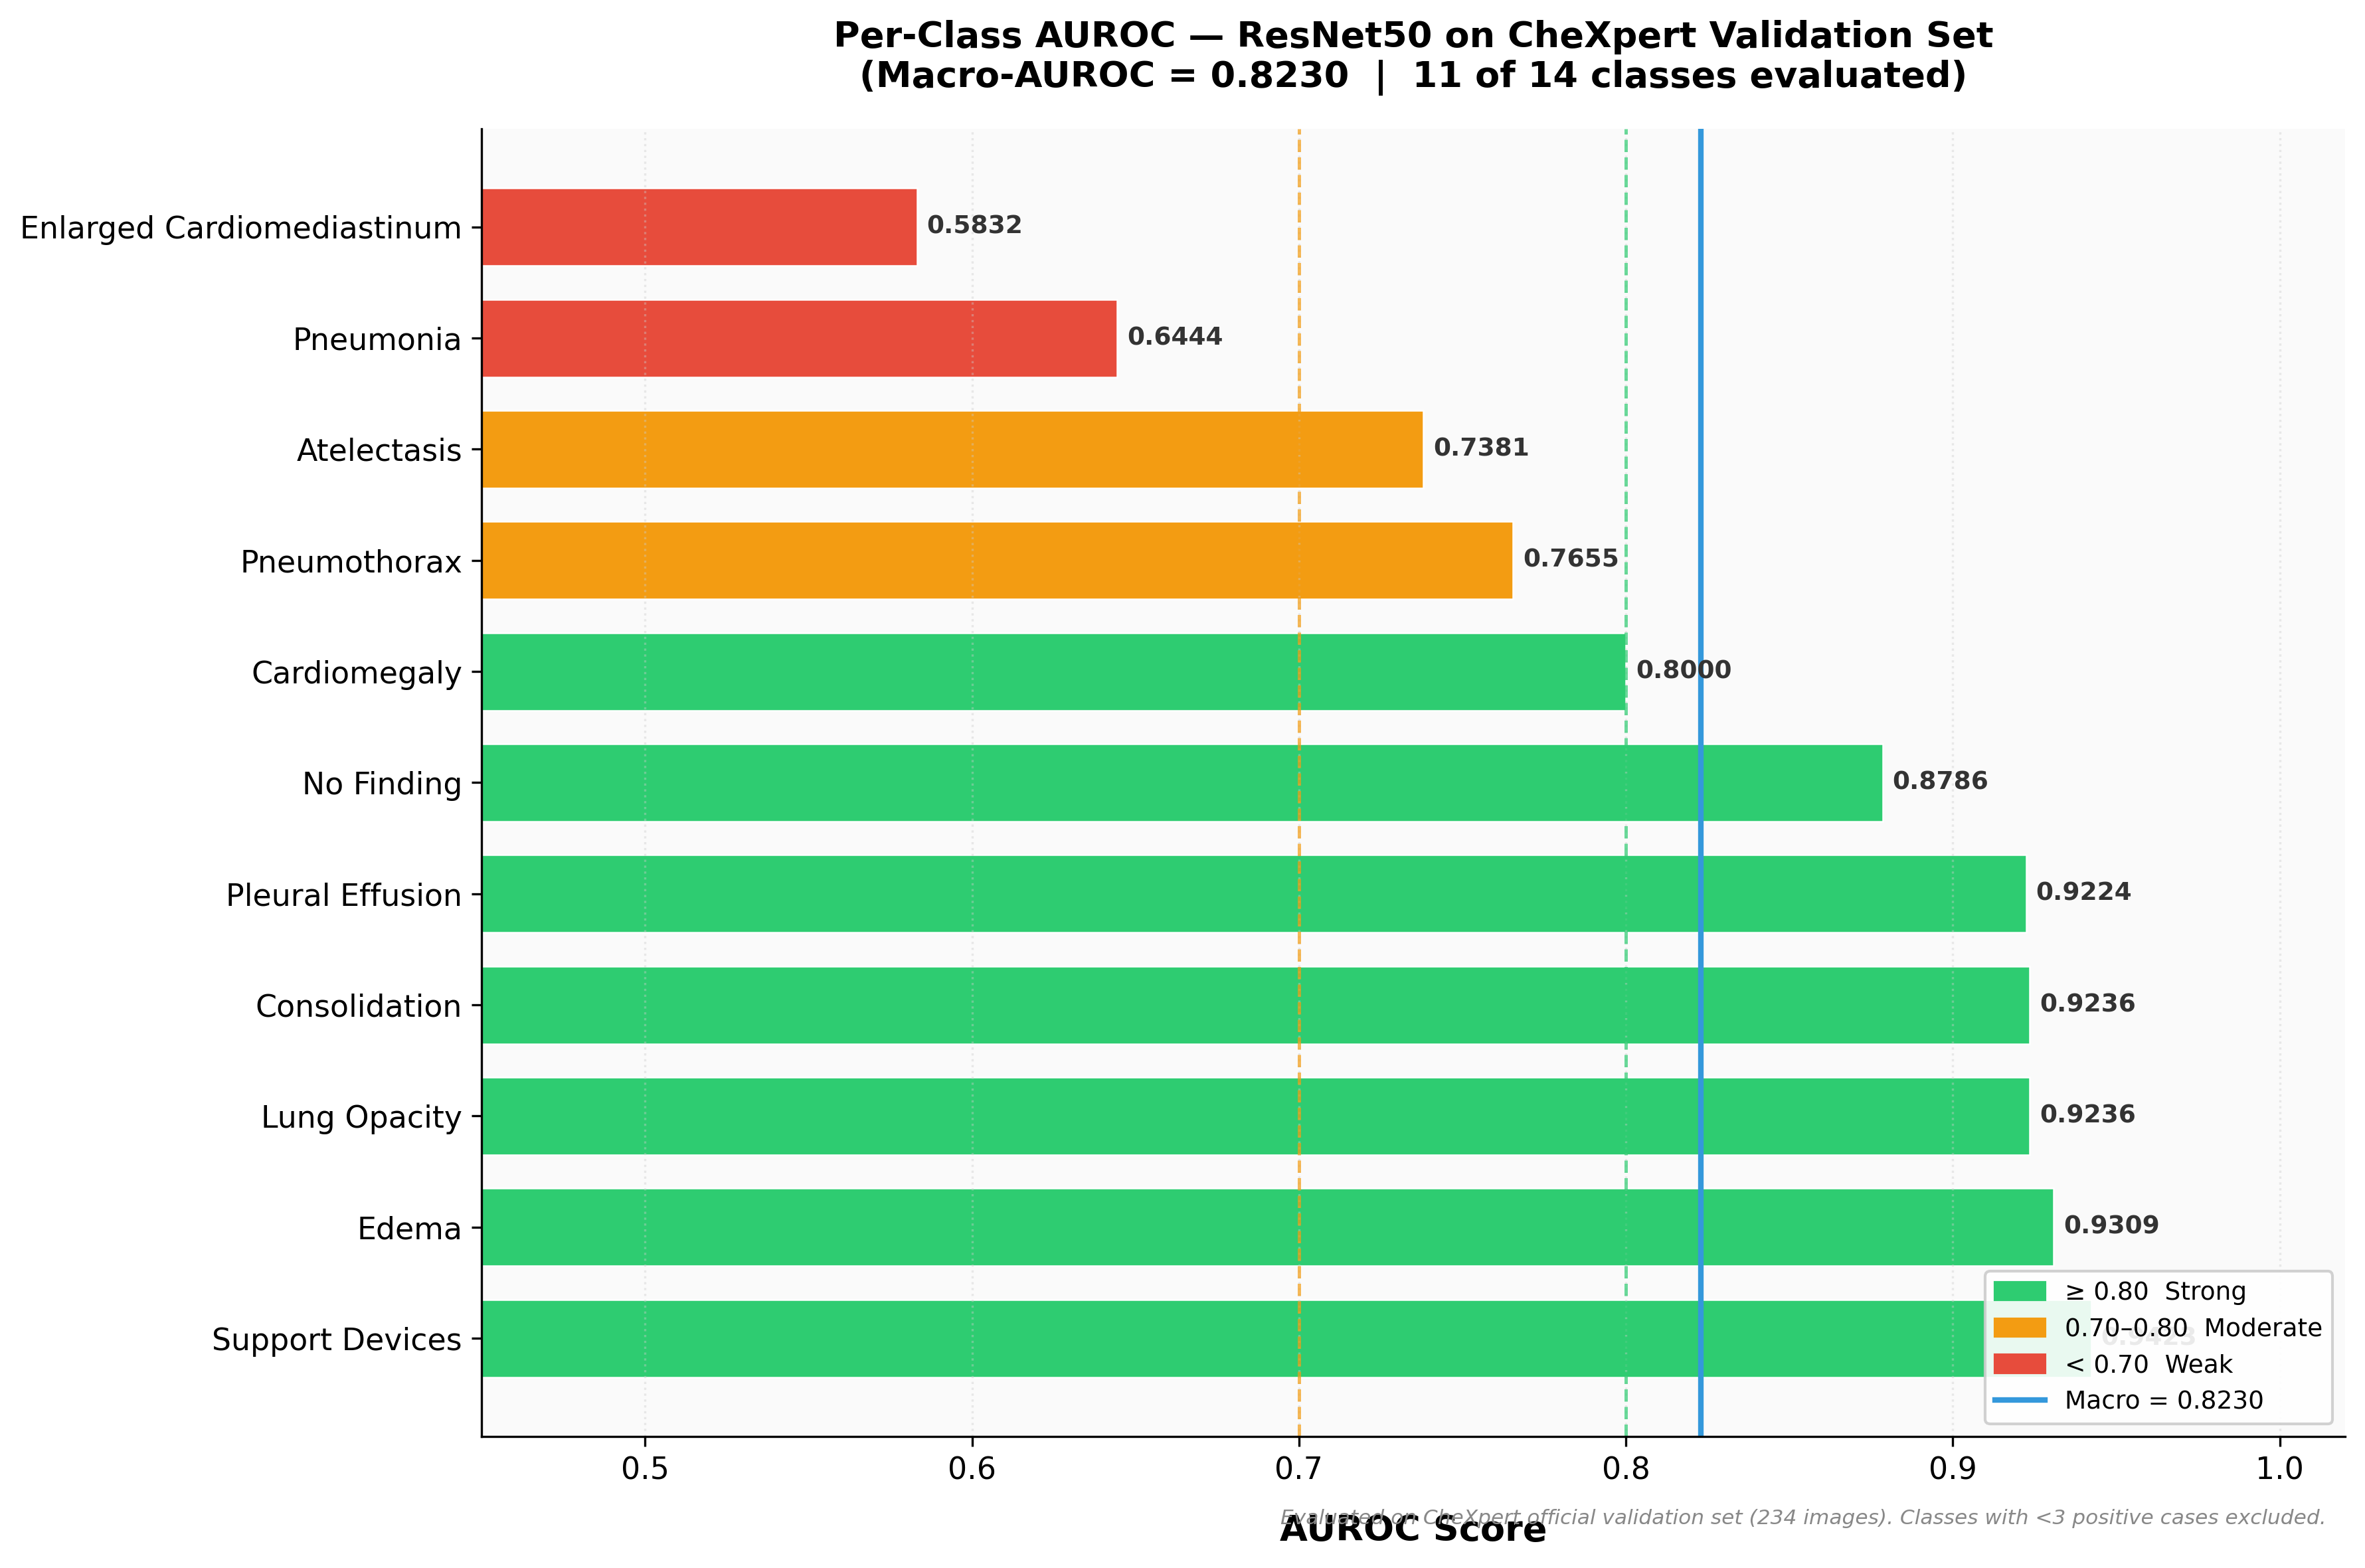

✅ Saved → fig_per_class_auroc_300dpi.png


In [17]:
# ═══════════════════════════════════════════════
# CELL 9: VIZ 1 — Per-Class AUROC (Best Model)
# 300 DPI, Thesis-Ready
# ═══════════════════════════════════════════════

valid_classes = {k: v for k, v in best_results['per_class'].items()
                 if v is not None}
classes = list(valid_classes.keys())
aurocs  = list(valid_classes.values())

# Sort descending
sorted_pairs = sorted(zip(aurocs, classes), reverse=True)
aurocs_sorted  = [x[0] for x in sorted_pairs]
classes_sorted = [x[1] for x in sorted_pairs]

# Color coding
bar_colors = ['#2ecc71' if a >= 0.80 else
              '#f39c12' if a >= 0.70 else
              '#e74c3c' for a in aurocs_sorted]

fig, ax = plt.subplots(figsize=(12, 8), dpi=300)
fig.patch.set_facecolor('white')

bars = ax.barh(classes_sorted, aurocs_sorted,
               color=bar_colors, edgecolor='white',
               linewidth=0.6, height=0.7)

# Value labels on bars
for bar, val in zip(bars, aurocs_sorted):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left',
            fontsize=9, fontweight='bold', color='#333333')

# Reference lines
ax.axvline(0.80, color='#2ecc71', linestyle='--', lw=1.2,
           alpha=0.7, label='0.80 — Strong')
ax.axvline(0.70, color='#f39c12', linestyle='--', lw=1.2,
           alpha=0.7, label='0.70 — Moderate')
ax.axvline(best_results['macro'], color='#3498db',
           linestyle='-', lw=2.0,
           label=f'Macro-AUROC = {best_results["macro"]:.4f}')

# Styling
ax.set_xlabel('AUROC Score', fontsize=13, fontweight='bold', labelpad=10)
ax.set_title(f'Per-Class AUROC — ResNet50 on CheXpert Validation Set\n'
             f'(Macro-AUROC = {best_results["macro"]:.4f}  |  '
             f'{len(valid_classes)} of {NUM_CLASSES} classes evaluated)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0.45, 1.02)
ax.set_facecolor('#fafafa')
ax.grid(axis='x', alpha=0.4, linestyle=':', color='#cccccc')
ax.spines[['top', 'right']].set_visible(False)

legend_handles = [
    mpatches.Patch(color='#2ecc71', label='≥ 0.80  Strong'),
    mpatches.Patch(color='#f39c12', label='0.70–0.80  Moderate'),
    mpatches.Patch(color='#e74c3c', label='< 0.70  Weak'),
    plt.Line2D([0], [0], color='#3498db', lw=2,
               label=f'Macro = {best_results["macro"]:.4f}'),
]
ax.legend(handles=legend_handles, loc='lower right',
          fontsize=9, framealpha=0.9)

ax.text(0.99, -0.07,
        'Evaluated on CheXpert official validation set (234 images). '
        'Classes with <3 positive cases excluded.',
        ha='right', va='bottom', transform=ax.transAxes,
        fontsize=7.5, color='#888888', style='italic')

plt.tight_layout()
plt.savefig('/kaggle/working/fig_per_class_auroc_300dpi.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved → fig_per_class_auroc_300dpi.png")


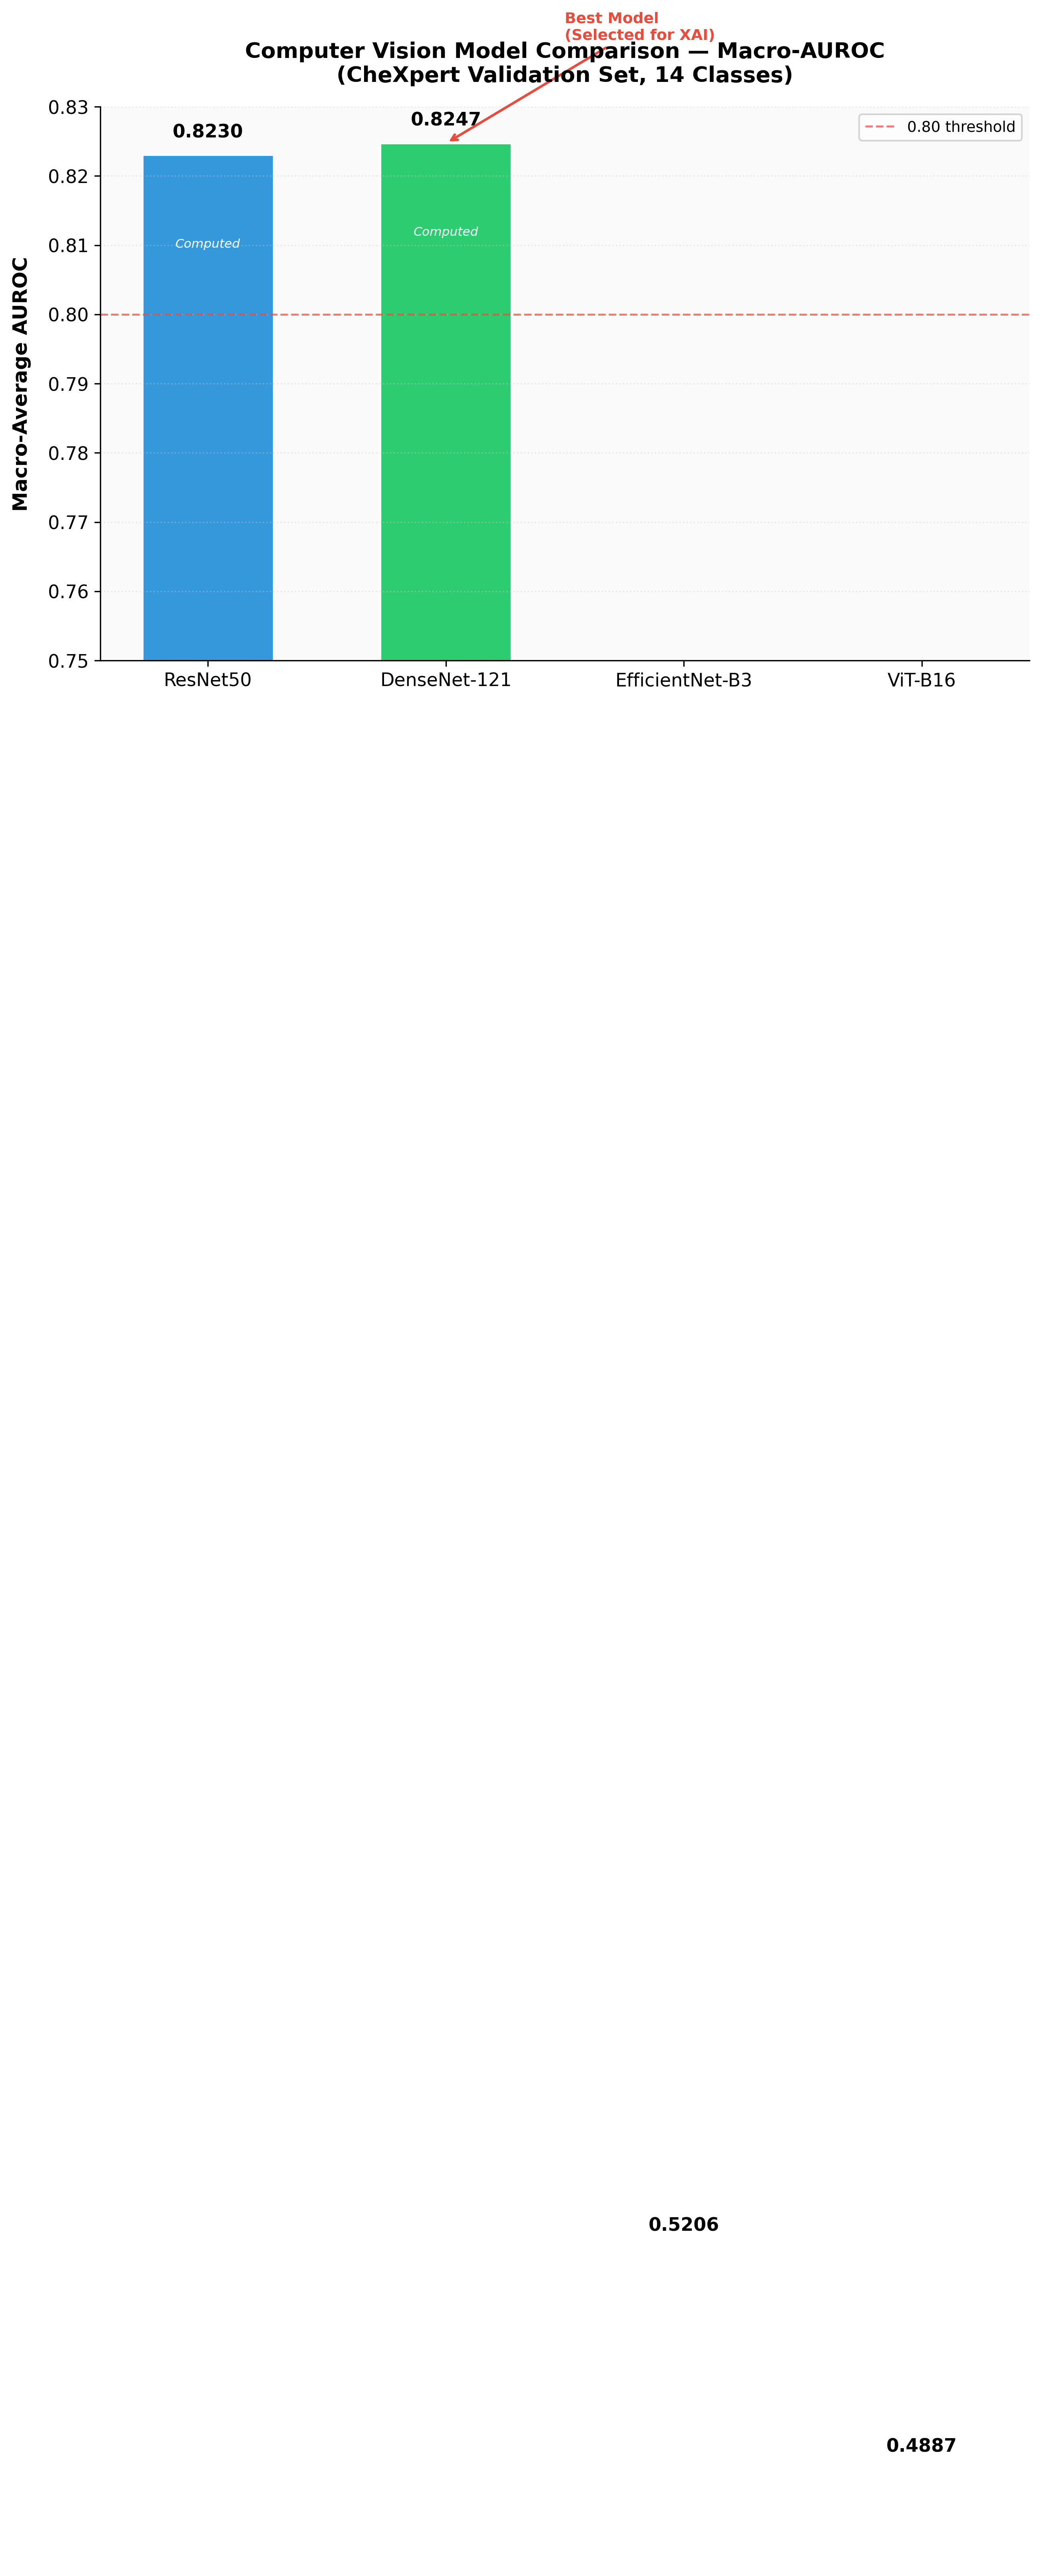

✅ Saved → fig_model_comparison_300dpi.png


In [18]:
# ═══════════════════════════════════════════════
# CELL 10: VIZ 2 — 4-Model Macro-AUROC Comparison
# 300 DPI, Thesis-Ready
# ═══════════════════════════════════════════════

model_names = list(KNOWN_AUROC.keys())
macro_aucs  = []
sources     = []

for m in model_names:
    if m in ALL_RESULTS:
        macro_aucs.append(ALL_RESULTS[m]['macro'])
        sources.append('Computed')
    else:
        macro_aucs.append(KNOWN_AUROC[m])
        sources.append('Training log')

colors = ['#2ecc71' if a == max(macro_aucs) else '#3498db'
          for a in macro_aucs]

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)
fig.patch.set_facecolor('white')

bars = ax.bar(model_names, macro_aucs,
              color=colors, edgecolor='white',
              linewidth=0.8, width=0.55)

# Value labels
for bar, val, src in zip(bars, macro_aucs, sources):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.002, f'{val:.4f}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2,
            val - 0.012, src,
            ha='center', va='top',
            fontsize=7.5, color='white', style='italic')

# Best model annotation
best_idx = macro_aucs.index(max(macro_aucs))
ax.annotate('Best Model\n(Selected for XAI)',
            xy=(best_idx, max(macro_aucs)),
            xytext=(best_idx + 0.5, max(macro_aucs) + 0.015),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5),
            fontsize=9, color='#e74c3c', fontweight='bold')

ax.set_ylim(0.75, 0.83)
ax.set_ylabel('Macro-Average AUROC', fontsize=12,
              fontweight='bold', labelpad=10)
ax.set_title('Computer Vision Model Comparison — Macro-AUROC\n'
             '(CheXpert Validation Set, 14 Classes)',
             fontsize=13, fontweight='bold', pad=15)
ax.axhline(0.80, color='#e74c3c', linestyle='--',
           lw=1.2, alpha=0.7, label='0.80 threshold')
ax.set_facecolor('#fafafa')
ax.grid(axis='y', alpha=0.4, linestyle=':', color='#cccccc')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('/kaggle/working/fig_model_comparison_300dpi.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved → fig_model_comparison_300dpi.png")


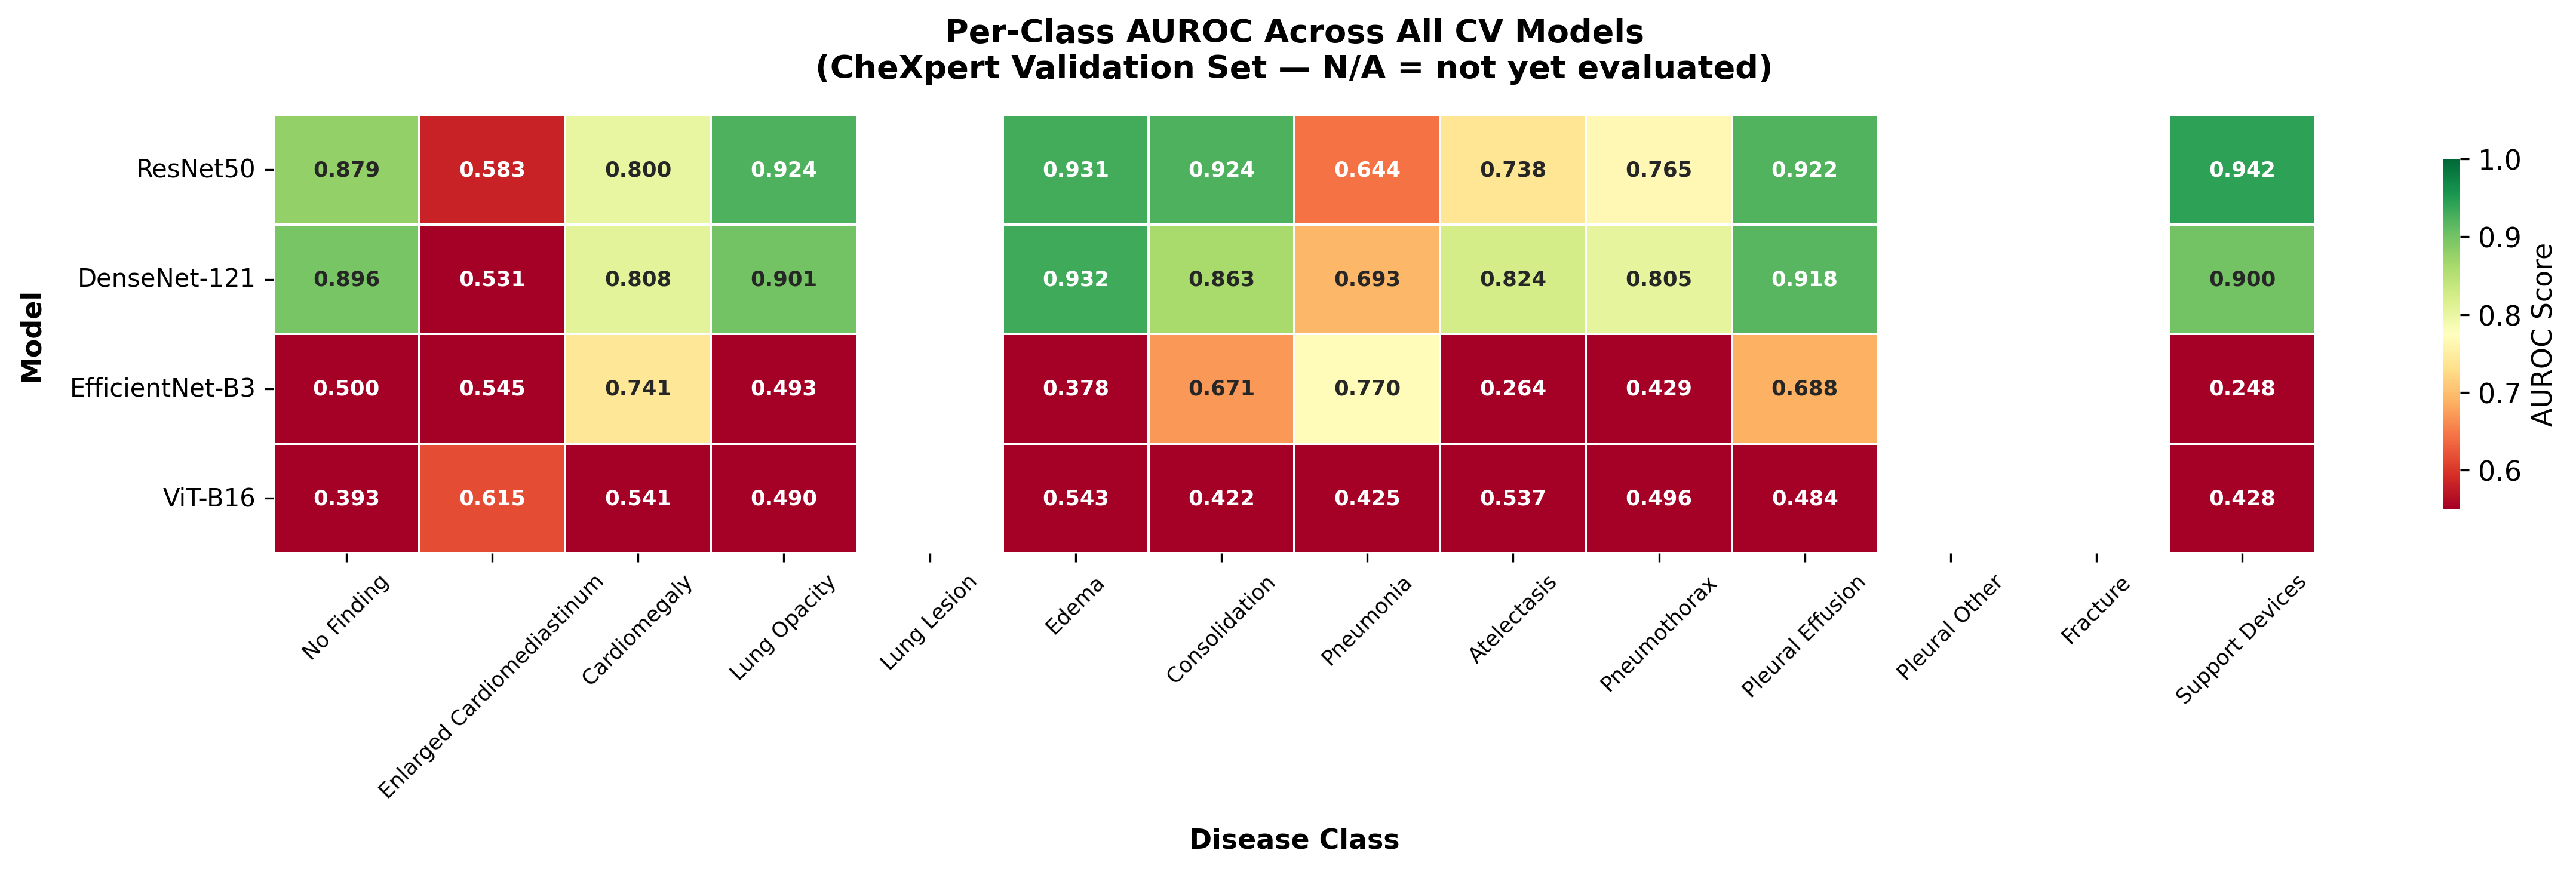

✅ Saved → fig_auroc_heatmap_300dpi.png


In [19]:
# ═══════════════════════════════════════════════
# CELL 11: VIZ 3 — AUROC Heatmap (all models × all classes)
# 300 DPI, Thesis-Ready
# ═══════════════════════════════════════════════

# Build matrix: rows = models, cols = classes
heatmap_data = {}
for m in model_names:
    if m in ALL_RESULTS:
        row = [ALL_RESULTS[m]['per_class'].get(c) for c in LABEL_NAMES]
    else:
        # Fill with None — shown as grey in heatmap
        row = [None] * NUM_CLASSES
    heatmap_data[m] = row

df_heat = pd.DataFrame(heatmap_data, index=LABEL_NAMES).T.astype(float)

fig, ax = plt.subplots(figsize=(16, 5), dpi=300)
fig.patch.set_facecolor('white')

mask = df_heat.isnull()

sns.heatmap(df_heat,
            mask=mask,
            annot=True, fmt='.3f',
            cmap='RdYlGn',
            vmin=0.55, vmax=1.00,
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'AUROC Score', 'shrink': 0.8},
            annot_kws={'size': 8.5, 'weight': 'bold'},
            ax=ax)

# Grey out cells with no data
sns.heatmap(df_heat,
            mask=~mask,
            annot=pd.DataFrame(
                [['N/A']*NUM_CLASSES for _ in model_names],
                index=model_names, columns=LABEL_NAMES
            ),
            fmt='',
            cmap=['#dddddd'],
            cbar=False,
            linewidths=0.5,
            linecolor='white',
            ax=ax)

ax.set_title('Per-Class AUROC Across All CV Models\n'
             '(CheXpert Validation Set — N/A = not yet evaluated)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Disease Class', fontsize=11, fontweight='bold', labelpad=10)
ax.set_ylabel('Model', fontsize=11, fontweight='bold', labelpad=10)
ax.tick_params(axis='x', rotation=45, labelsize=8.5)
ax.tick_params(axis='y', rotation=0,  labelsize=10)

plt.tight_layout()
plt.savefig('/kaggle/working/fig_auroc_heatmap_300dpi.png',
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved → fig_auroc_heatmap_300dpi.png")


In [20]:
# ═══════════════════════════════════════════════
# CELL 12: Download Links
# ═══════════════════════════════════════════════
from IPython.display import FileLink, display

outputs = [
    ('per_class_auroc_resnet50.csv',    'Per-class AUROC table (CSV)'),
    ('fig_per_class_auroc_300dpi.png',  'VIZ 1 — Per-class bar chart (300 DPI)'),
    ('fig_model_comparison_300dpi.png', 'VIZ 2 — Model comparison (300 DPI)'),
    ('fig_auroc_heatmap_300dpi.png',    'VIZ 3 — AUROC heatmap (300 DPI)'),
]

print("DOWNLOAD LINKS")
print("=" * 55)
for fname, label in outputs:
    fpath = f'/kaggle/working/{fname}'
    if os.path.exists(fpath):
        size_kb = os.path.getsize(fpath) / 1024
        print(f"\n  {label}  ({size_kb:.0f} KB)")
        display(FileLink(fname))
    else:
        print(f"\n  {fname} — not yet generated")
print("\nAlso available in Kaggle → Output tab (right panel)")


📥 DOWNLOAD LINKS

  Per-class AUROC table (CSV)  (0 KB)


/kaggle/working/per_class_auroc_resnet50.csv


  VIZ 1 — Per-class bar chart (300 DPI)  (334 KB)


/kaggle/working/fig_per_class_auroc_300dpi.png


  VIZ 2 — Model comparison (300 DPI)  (254 KB)


/kaggle/working/fig_model_comparison_300dpi.png


  VIZ 3 — AUROC heatmap (300 DPI)  (384 KB)


/kaggle/working/fig_auroc_heatmap_300dpi.png


💡 Also available in Kaggle → Output tab (right panel)
